La interpretación geométrica del filtro de Savitzky-Golay en una dimensión, especialmente para un filtro de grado 2, puede entenderse desde la forma que tiene el polinomio ajustado a los datos. Cuando se usa un filtro de Savitzky-Golay de grado 2, el filtro busca ajustar una parábola a los puntos locales de la señal. Esto implica que el filtro tenderá a "responder mejor" o a suavizar más eficientemente en regiones de la señal que puedan aproximarse a una forma parabólica.

Desde esta perspectiva, la primera componente del filtro —es decir, el primer valor en la secuencia de coeficientes que aplica el filtro— puede interpretarse como una medida de qué tan fuerte es la contribución de una parábola en esa región local. Por tanto:

- En términos geométricos, podríamos decir que el filtro "detecta" o "resalta" formas que se aproximan a curvas cuadráticas (parabólicas).
- Si la señal tiene una estructura de parábola (o una porción que se parece a una parábola en una ventana de datos), el filtro de grado 2 suavizará estos datos sin distorsionarlos tanto como lo haría en segmentos lineales o en segmentos con curvaturas diferentes (por ejemplo, más agudas o menos pronunciadas que una parábola).

En este sentido, el filtro actúa casi como un "detector de parábolas", porque los coeficientes del filtro de grado 2 están configurados para interpretar los datos como si provinieran de una función cuadrática. Para valores de la señal que no tienen esta estructura cuadrática localmente, el filtro sigue suavizando, pero con una mayor distorsión relativa en comparación con regiones parabólicas, ya que la aproximación cuadrática no es tan adecuada.

En resumen, sí se puede interpretar que, al usar un filtro de Savitzky-Golay de grado 2, estamos resaltando o priorizando regiones de la señal con comportamientos similares a una parábola, y el primer coeficiente de ese filtro reflejaría la sensibilidad hacia ese tipo de formas en la señal.

Exactamente, al ampliar la interpretación geométrica del filtro de Savitzky-Golay, es posible considerar que las componentes de los coeficientes del filtro de grado 2 no solo suavizan y resaltan las formas parabólicas, sino que también contienen información sobre el desplazamiento y la simetría de la parábola, lo que permite extraer datos sobre la "posición" de su vértice.

Para profundizar en esta idea:

1. **Primera componente (valor central):** Indica el valor promedio de la señal en el intervalo de la ventana, suavizando los datos sin grandes cambios locales. Este valor representa la "base" de la parábola ajustada en la región.

2. **Segunda componente (derivada):** En este contexto, la segunda componente puede interpretarse como una estimación de la derivada o pendiente local. Este coeficiente revela cómo cambia la señal dentro de la ventana, lo cual está relacionado con la inclinación de la parábola en un punto específico.

3. **Combinación para encontrar el centro (vértice de la parábola):** Los coeficientes del filtro permiten deducir la posición aproximada del centro o vértice de la parábola en la ventana de datos. En otras palabras, la combinación de la primera y segunda componentes puede ayudar a identificar el punto donde la curva alcanza su mínimo o máximo local (dependiendo de la orientación de la parábola).

    - **Posición del vértice:** Si consideramos los datos dentro de la ventana como una parábola \( f(x) = ax^2 + bx + c \), los coeficientes del filtro nos proporcionan aproximaciones a los valores \( a \) (curvatura), \( b \) (pendiente), y \( c \) (intersección). El vértice de esta parábola se encuentra en \( x = -\frac{b}{2a} \), indicando el punto en el cual la parábola cambia de dirección. 

En la práctica, al analizar estos coeficientes, podemos identificar el centro de la parábola en la ventana de datos, lo cual es útil en contextos donde queremos detectar características geométricas específicas, como picos, valles o curvaturas de transición en una señal.

Entonces, en resumen, la interpretación geométrica del filtro de Savitzky-Golay permite no solo suavizar los datos, sino también extraer información sobre la estructura local de la señal. En particular, al interpretar las primeras dos componentes, podemos deducir la posición de características significativas como el centro de una parábola, lo que añade una capa de análisis geométrico muy útil en el procesamiento de señales.

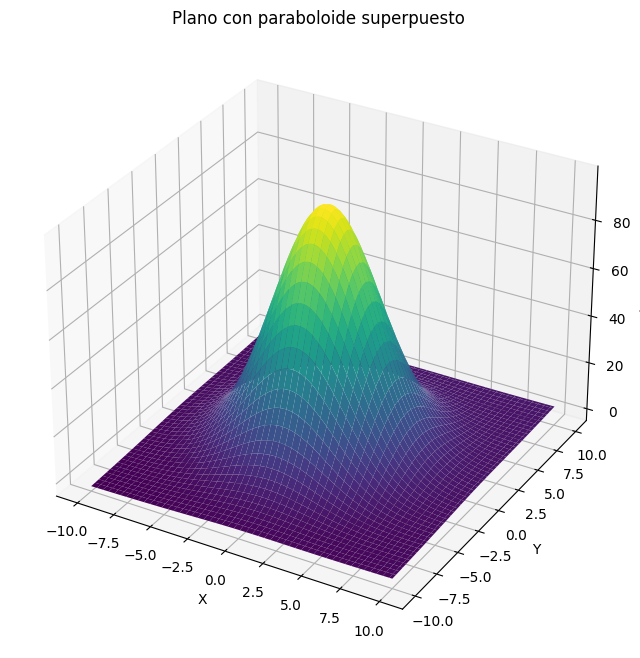

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generar un grid para la imagen en 2D
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)

# Crear un plano base y un paraboloide en el centro
plane = 0.1 * X + 0.2 * Y  # Plano inclinado
paraboloid = 100 * np.exp(-0.05 * (X**2 + Y**2))  # Paraboloide en el centro
Z = plane + paraboloid  # Combinar el plano y el paraboloide

# Graficar la superficie
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_title("Plano con paraboloide superpuesto")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Altura (Z)")

plt.show()


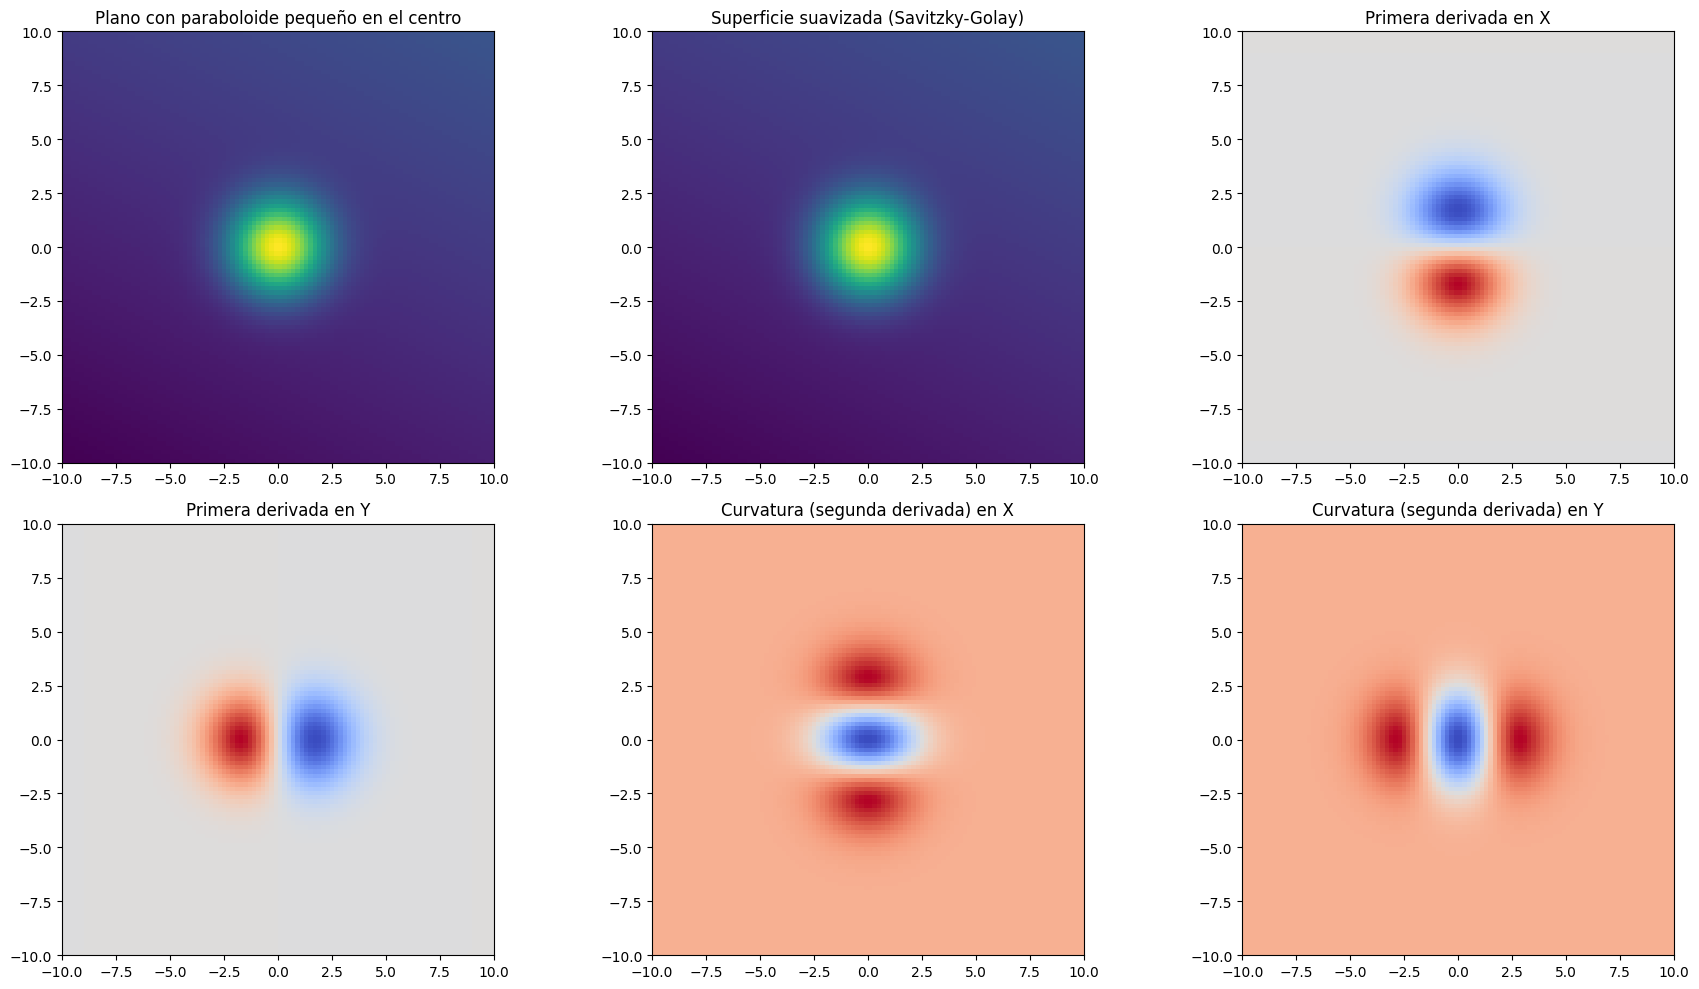

In [2]:
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

# Crear un paraboloide mucho más pequeño en el centro
paraboloid_small = 20 * np.exp(-0.2 * (X**2 + Y**2))  # Paraboloide más pequeño en el centro
Z = plane + paraboloid_small  # Combinar el plano y el paraboloide pequeño

# Aplicar el filtro de Savitzky-Golay en 2D para suavizar la superficie
Z_smoothed = savgol_filter(Z, window_length=15, polyorder=2, axis=0)  # Suavizar en la dirección X
Z_smoothed = savgol_filter(Z_smoothed, window_length=15, polyorder=2, axis=1)  # Suavizar en la dirección Y

# Derivadas en X y Y usando el filtro de Savitzky-Golay
Z_derivative_x = savgol_filter(Z, window_length=15, polyorder=2, deriv=1, axis=0)
Z_derivative_y = savgol_filter(Z, window_length=15, polyorder=2, deriv=1, axis=1)

# Segunda derivada para curvatura en X y Y
Z_curvature_x = savgol_filter(Z, window_length=15, polyorder=2, deriv=2, axis=0)
Z_curvature_y = savgol_filter(Z, window_length=15, polyorder=2, deriv=2, axis=1)

# Graficar resultados
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Imagen original con el paraboloide
axs[0, 0].imshow(Z, extent=[-10, 10, -10, 10], cmap='viridis', origin='lower')
axs[0, 0].set_title("Plano con paraboloide pequeño en el centro")

# Superficie suavizada
axs[0, 1].imshow(Z_smoothed, extent=[-10, 10, -10, 10], cmap='viridis', origin='lower')
axs[0, 1].set_title("Superficie suavizada (Savitzky-Golay)")

# Derivada en X
axs[0, 2].imshow(Z_derivative_x, extent=[-10, 10, -10, 10], cmap='coolwarm', origin='lower')
axs[0, 2].set_title("Primera derivada en X")

# Derivada en Y
axs[1, 0].imshow(Z_derivative_y, extent=[-10, 10, -10, 10], cmap='coolwarm', origin='lower')
axs[1, 0].set_title("Primera derivada en Y")

# Curvatura en X
axs[1, 1].imshow(Z_curvature_x, extent=[-10, 10, -10, 10], cmap='coolwarm', origin='lower')
axs[1, 1].set_title("Curvatura (segunda derivada) en X")

# Curvatura en Y
axs[1, 2].imshow(Z_curvature_y, extent=[-10, 10, -10, 10], cmap='coolwarm', origin='lower')
axs[1, 2].set_title("Curvatura (segunda derivada) en Y")

plt.tight_layout()
plt.show()


Un paraboloide puede describirse en coordenadas 3D \((x, y, z)\) mediante la ecuación general:

\[
z = ax^2 + by^2 + c
\]

Aquí, \(a\) y \(b\) controlan la curvatura en las direcciones \(x\) y \(y\), respectivamente, mientras que \(c\) es un desplazamiento en altura. Esta ecuación describe un paraboloide que tiene un punto más alto o bajo en el centro (dependiendo de los signos de \(a\) y \(b\)).

Al aplicar el filtro de Savitzky-Golay 2D al paraboloide sobre el plano, se obtienen diferentes componentes que nos permiten analizar la forma del paraboloide en función de sus pendientes y curvaturas.

A continuación, relacionamos cada componente de la imagen con las propiedades de la ecuación de un paraboloide:

1. **Superficie Original**:
   - Esta imagen muestra el paraboloide sobre un plano. 
   - La ecuación en este caso se combina con un plano inclinado de fondo, por lo que el paraboloide sigue la forma \(z = ax^2 + by^2 + c + dx + ey\), donde \(d\) y \(e\) son los coeficientes del plano lineal.
   
2. **Superficie Suavizada con Filtro Savitzky-Golay 2D**:
   - La superficie suavizada representa la función \(z\) con ruido reducido, realzando la curvatura del paraboloide. Esto facilita ver la estructura básica \(z = ax^2 + by^2 + c\) en el centro, ya que el filtro ha eliminado las variaciones bruscas.
   
3. **Primera Derivada en \(x\) y \(y\)**:
   - Las derivadas en \(x\) y \(y\) representan las pendientes locales en cada dirección. Para un paraboloide, estas derivadas siguen las ecuaciones:
     \[
     \frac{\partial z}{\partial x} = 2ax + d
     \]
     \[
     \frac{\partial z}{\partial y} = 2by + e
     \]
   - Las derivadas en \(x\) y \(y\) muestran cómo cambia la altura \(z\) en función de \(x\) y \(y\), lo cual es especialmente visible en los alrededores del paraboloide en el centro. Las derivadas alcanzan su valor mínimo o máximo en el centro del paraboloide, donde la pendiente es cero.

4. **Curvatura (segunda derivada) en \(x\) y \(y\)**:
   - La segunda derivada en cada dirección mide la curvatura, que describe cómo cambia la pendiente a lo largo de cada eje. Para un paraboloide, estas derivadas se expresan como constantes:
     \[
     \frac{\partial^2 z}{\partial x^2} = 2a
     \]
     \[
     \frac{\partial^2 z}{\partial y^2} = 2b
     \]
   - La curvatura en \(x\) y \(y\) muestra los valores constantes de \(2a\) y \(2b\), que determinan la forma del paraboloide en cada dirección. Esto es útil para identificar la concavidad del paraboloide y su orientación (si es abierto hacia arriba o hacia abajo).

### Resumen de Interpretación:

- **Superficie original y suavizada** reflejan la forma general del paraboloide y del plano.
- **Primera derivada** muestra las pendientes en las direcciones \(x\) y \(y\), revelando los cambios de altura a medida que uno se mueve hacia o desde el centro del paraboloide.
- **Curvatura** en cada dirección indica cómo cambia la pendiente, directamente relacionado con los coeficientes \(a\) y \(b\) de la ecuación del paraboloide, ayudando a definir su forma y anchura.

Esta interpretación permite comprender la geometría de un paraboloide y analizarla detalladamente usando el filtro Savitzky-Golay en 2D.

Para calcular el kernel 2D de Savitzky-Golay en Python de una manera similar a la que se describe en tu código en C++, podemos construir una matriz jacobiana 
�
J que refleje los términos de un ajuste parabólico en dos dimensiones, y luego resolver el sistema usando álgebra matricial. Este proceso producirá el kernel 2D que se puede utilizar para aplicar el filtro.

Paso a Paso:
Construir el vector 
�
x y 
�
y: Crear una secuencia de valores que represente las posiciones relativas en la ventana del filtro, por ejemplo, 
[
−
�
,
�
]
[−k,k] con 
�
k como el radio de la ventana.

Definir la matriz 
�
J: Para cada punto en la ventana, incluir los términos de ajuste parabólico que incluirían el término constante, los términos lineales en 
�
x y 
�
y, y los términos cuadráticos.

Resolver el sistema: Usar álgebra matricial para obtener el kernel resultante.

Voy a implementar este proceso en Python para calcular el kernel 2D.

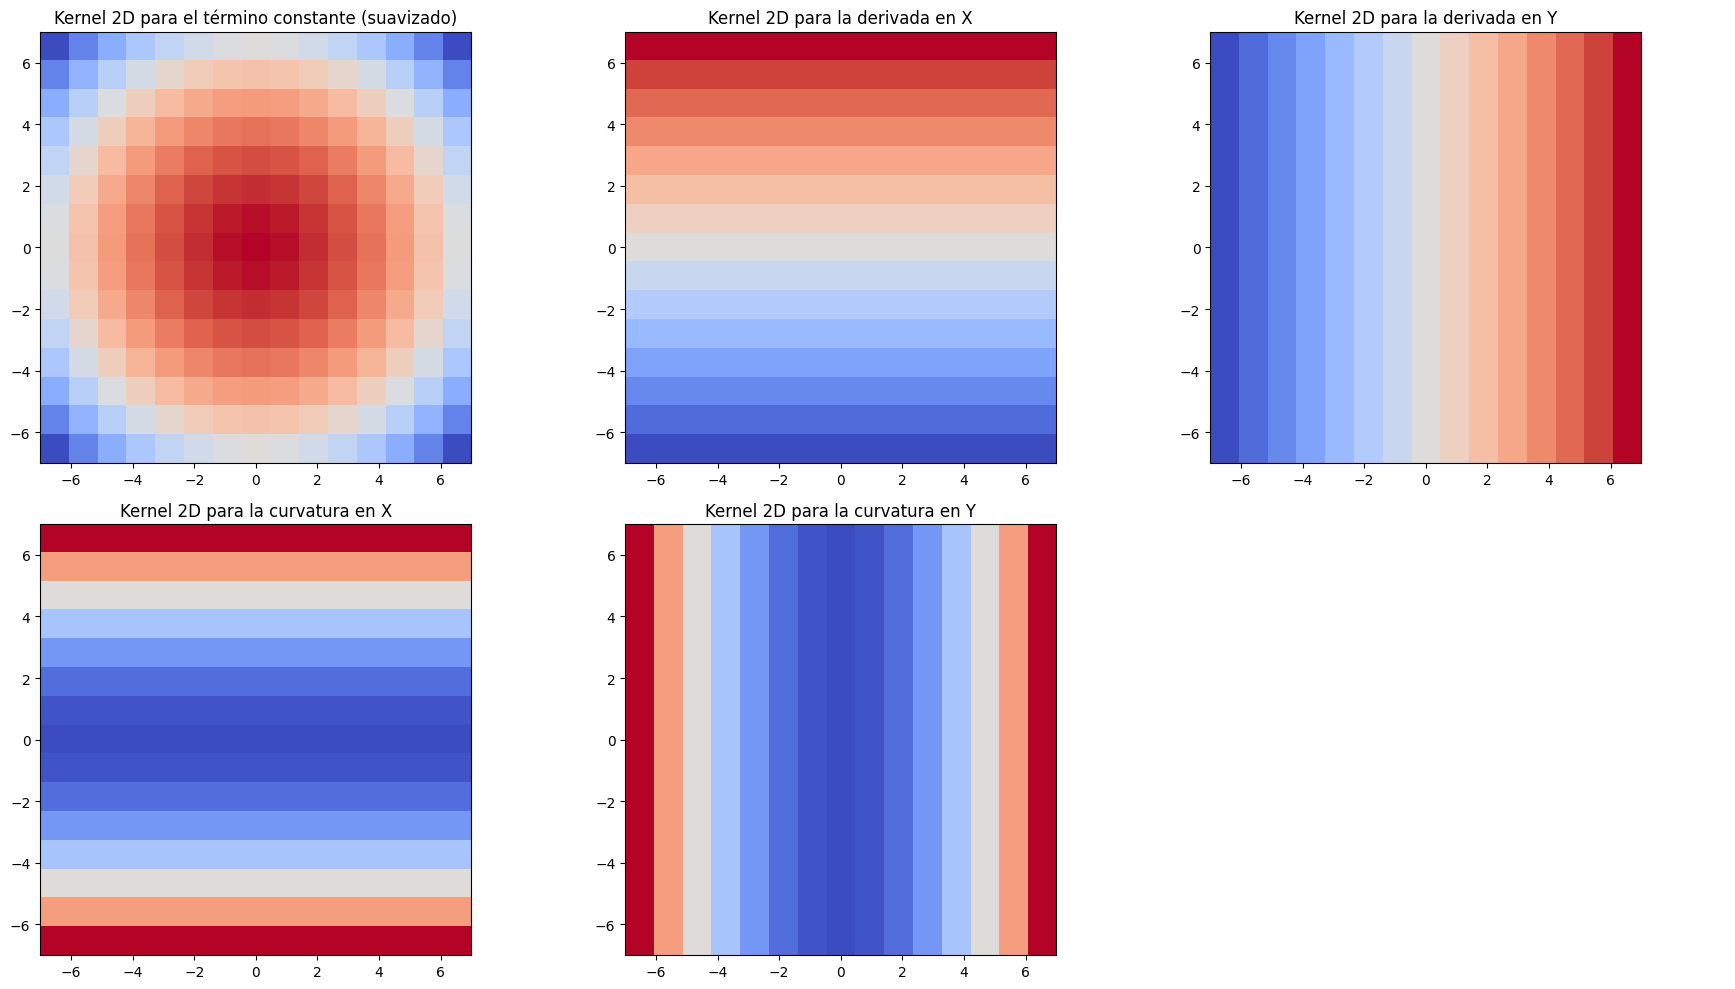

In [3]:
def savgol_2d_kernels(window_size, poly_order=2):
    # Definir el radio (half-size) y el tamaño completo de la ventana
    half_size = (window_size - 1) // 2
    full_size = window_size

    # Crear el vector de posiciones relativas en x e y
    x = np.arange(-half_size, half_size + 1)
    
    # Crear la matriz Jacobiana J con los términos de la parábola
    J = np.zeros((full_size * full_size, 5))
    for i, xi in enumerate(x):
        for j, yj in enumerate(x):
            row = i * full_size + j
            J[row] = [1, xi, yj, xi**2, yj**2]  # Constante, lineal x, lineal y, cuadrático x, cuadrático y

    # Calcular (J^T * J)^-1 * J^T para obtener los coeficientes de cada término
    Jt = J.T
    iJtxJ = np.linalg.pinv(Jt @ J)  # Moore-Penrose inverse in case Jt * J is not invertible
    C = iJtxJ @ Jt

    # Extraer los kernels para el término constante, derivadas en x, y, y curvaturas
    kernel_constant = C[0].reshape((full_size, full_size))
    kernel_derivative_x = C[1].reshape((full_size, full_size))
    kernel_derivative_y = C[2].reshape((full_size, full_size))
    kernel_curvature_x = C[3].reshape((full_size, full_size))
    kernel_curvature_y = C[4].reshape((full_size, full_size))
    
    return kernel_constant, kernel_derivative_x, kernel_derivative_y, kernel_curvature_x, kernel_curvature_y

# Calcular los kernels de Savitzky-Golay para el término constante y las derivadas
kernel_constant, kernel_derivative_x, kernel_derivative_y, kernel_curvature_x, kernel_curvature_y = savgol_2d_kernels(15)

# Graficar los kernels
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Kernel para el término constante (suavizado)
axs[0, 0].imshow(kernel_constant, cmap='coolwarm', extent=[-7, 7, -7, 7], origin='lower')
axs[0, 0].set_title("Kernel 2D para el término constante (suavizado)")

# Kernel para la derivada en X
axs[0, 1].imshow(kernel_derivative_x, cmap='coolwarm', extent=[-7, 7, -7, 7], origin='lower')
axs[0, 1].set_title("Kernel 2D para la derivada en X")

# Kernel para la derivada en Y
axs[0, 2].imshow(kernel_derivative_y, cmap='coolwarm', extent=[-7, 7, -7, 7], origin='lower')
axs[0, 2].set_title("Kernel 2D para la derivada en Y")

# Kernel para la curvatura en X (segunda derivada)
axs[1, 0].imshow(kernel_curvature_x, cmap='coolwarm', extent=[-7, 7, -7, 7], origin='lower')
axs[1, 0].set_title("Kernel 2D para la curvatura en X")

# Kernel para la curvatura en Y (segunda derivada)
axs[1, 1].imshow(kernel_curvature_y, cmap='coolwarm', extent=[-7, 7, -7, 7], origin='lower')
axs[1, 1].set_title("Kernel 2D para la curvatura en Y")

# Ocultar el último subplot
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()



Kernel para la derivada cruzada
En un filtro de Savitzky-Golay, el kernel correspondiente a 
∂
2
�
∂
�
∂
�
∂x∂y
∂ 
2
 z
​
  se puede calcular de la misma manera que los demás kernels, resolviendo el sistema de ajuste, pero seleccionando el término específico para esta derivada cruzada.

Voy a calcular este kernel y aplicarlo sobre la superficie para mostrar cómo se interpreta.

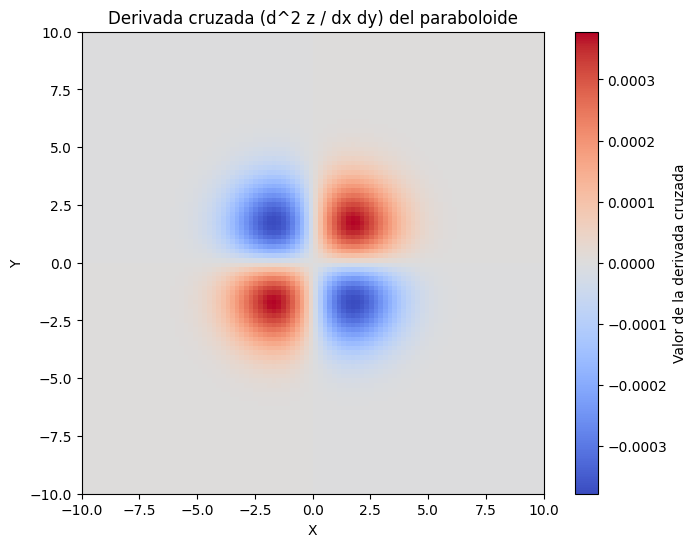

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

def savgol_2d_kernel_cross_derivative(window_size):
    # Definir el radio (half-size) y el tamaño completo de la ventana
    half_size = (window_size - 1) // 2
    full_size = window_size

    # Crear el vector de posiciones relativas en x e y
    x = np.arange(-half_size, half_size + 1)
    
    # Crear la matriz Jacobiana J con los términos de la parábola
    J = np.zeros((full_size * full_size, 5))
    for i, xi in enumerate(x):
        for j, yj in enumerate(x):
            row = i * full_size + j
            J[row] = [1, xi, yj, xi**2, yj**2]  # Constante, lineal x, lineal y, cuadrático x, cuadrático y

    # Calcular (J^T * J)^-1 * J^T para obtener los coeficientes de cada término
    Jt = J.T
    iJtxJ = np.linalg.pinv(Jt @ J)  # Moore-Penrose inverse in case Jt * J is not invertible
    C = iJtxJ @ Jt

    # Extraer el kernel para la derivada cruzada (d^2 z / dx dy)
    kernel_cross_derivative = (C[1] * C[2]).reshape((full_size, full_size))  # Cross-product kernel
    return kernel_cross_derivative

# Calcular el kernel para la derivada cruzada
kernel_cross_derivative = savgol_2d_kernel_cross_derivative(15)

# Aplicar el kernel sobre la imagen para calcular la derivada cruzada
Z_cross_derivative = convolve2d(Z, kernel_cross_derivative, mode='same', boundary='symm')

# Graficar el resultado de la derivada cruzada
plt.figure(figsize=(8, 6))
plt.imshow(Z_cross_derivative, extent=[-10, 10, -10, 10], cmap='coolwarm', origin='lower')
plt.colorbar(label='Valor de la derivada cruzada')
plt.title("Derivada cruzada (d^2 z / dx dy) del paraboloide")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


Escenario simulado:
- Creamos una señal de 4096 puntos con forma suave (tipo spline cúbico).
- Añadimos un bollo parabólico centrado.
- Aplicamos Savitzky-Golay para:
  - Suavizar la señal.
  - Calcular la segunda derivada.
  - Estimar la posición del bollo a partir del mínimo de curvatura (segunda derivada negativa máxima).

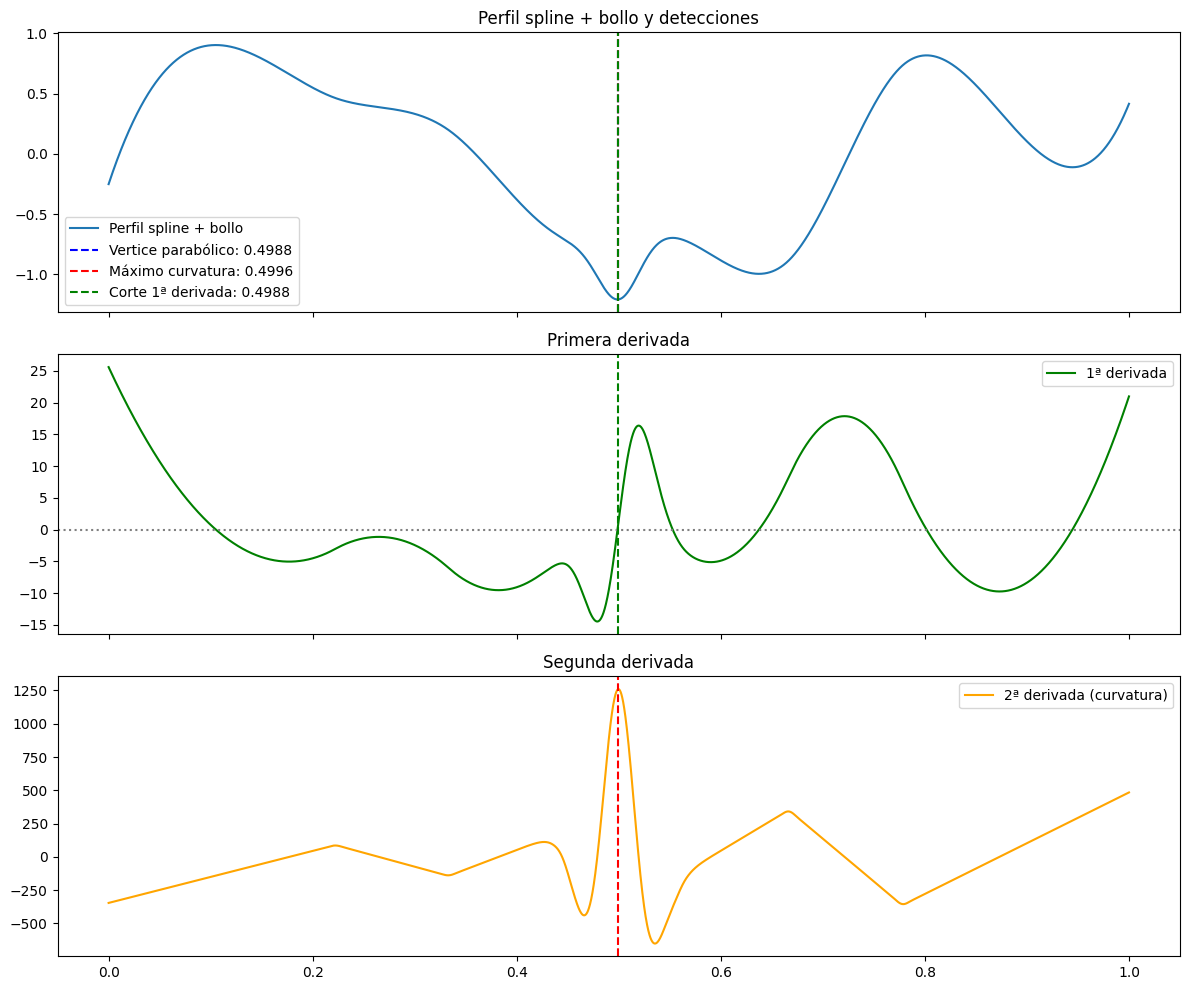

In [5]:
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

def detectar_bollo_sg(x, signal, window_length=101, poly_order=4, fit_window=10):
    """
    Versión mejorada:
    - Detecta el máximo de la 2ª derivada
    - Busca el cruce por cero de la 1ª derivada más cercano al máximo de curvatura
    - Ajusta parábola localmente para estimar el centro
    """
    dx = x[1] - x[0]
    d1 = savgol_filter(signal, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx)
    d2 = savgol_filter(signal, window_length=window_length, polyorder=poly_order, deriv=2, delta=dx)

    i_max2 = np.argmax(d2)
    x_max2 = x[i_max2]

    # Cruces por cero (1ª derivada)
    f_interp = interp1d(x, d1, kind='linear')
    sign_change_indices = np.where(np.diff(np.sign(d1)))[0]
    zero_crossings = []
    for idx in sign_change_indices:
        x0, x1 = x[idx], x[idx + 1]
        y0, y1 = d1[idx], d1[idx + 1]
        x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
        zero_crossings.append(x_zero)
    zero_crossings = np.array(zero_crossings)

    # Cruce más cercano al máximo de la segunda derivada
    i_closest_to_max2 = np.argmin(np.abs(zero_crossings - x_max2))
    zero_crossing_x = zero_crossings[i_closest_to_max2]

    # Ajuste parabólico local alrededor del máximo de curvatura
    fit_range = slice(i_max2 - fit_window, i_max2 + fit_window + 1)
    x_fit = x[fit_range] - x[i_max2]
    y_fit = signal[fit_range]
    a, b, c = np.polyfit(x_fit, y_fit, 2)
    vertex_x = x[i_max2] - b / (2 * a)

    return {
        'x_max2': x_max2,
        'x_zero': zero_crossing_x,
        'x_vertex': vertex_x,
        'd1': d1,
        'd2': d2
    }



# Generar nuevo fondo tipo spline cúbico aleatorio
x = np.linspace(0, 1, 4096)
np.random.seed(42)
knot_x = np.linspace(0, 1, 10)
knot_y = np.random.uniform(-1, 1, size=10)
spline = UnivariateSpline(knot_x, knot_y, k=3, s=0)
spline_base = spline(x)

#bollo gaussiano invertido
bump_center = 0.5
bump_width = 0.02
gaussian_bump = -0.5 * np.exp(-((x - bump_center) ** 2) / (2 * bump_width ** 2))

# Señal con bollo gaussiano sobre spline
signal_spline = spline_base + gaussian_bump

# Detectar bollo
res = detectar_bollo_sg(x, signal_spline)

# Graficar resultados
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].plot(x, signal_spline, label='Perfil spline + bollo')
axs[0].axvline(res['x_vertex'], color='blue', linestyle='--', label=f'Vertice parabólico: {res["x_vertex"]:.4f}')
axs[0].axvline(res['x_max2'], color='red', linestyle='--', label=f'Máximo curvatura: {res["x_max2"]:.4f}')
axs[0].axvline(res['x_zero'], color='green', linestyle='--', label=f'Corte 1ª derivada: {res["x_zero"]:.4f}')
axs[0].set_title("Perfil spline + bollo y detecciones")
axs[0].legend()

axs[1].plot(x, res['d1'], label='1ª derivada', color='green')
axs[1].axhline(0, color='gray', linestyle=':')
axs[1].axvline(res['x_zero'], color='green', linestyle='--')
axs[1].set_title("Primera derivada")
axs[1].legend()

axs[2].plot(x, res['d2'], label='2ª derivada (curvatura)', color='orange')
axs[2].axvline(res['x_max2'], color='red', linestyle='--')
axs[2].set_title("Segunda derivada")
axs[2].legend()

plt.tight_layout()
plt.show()


### Perfil ruidoso

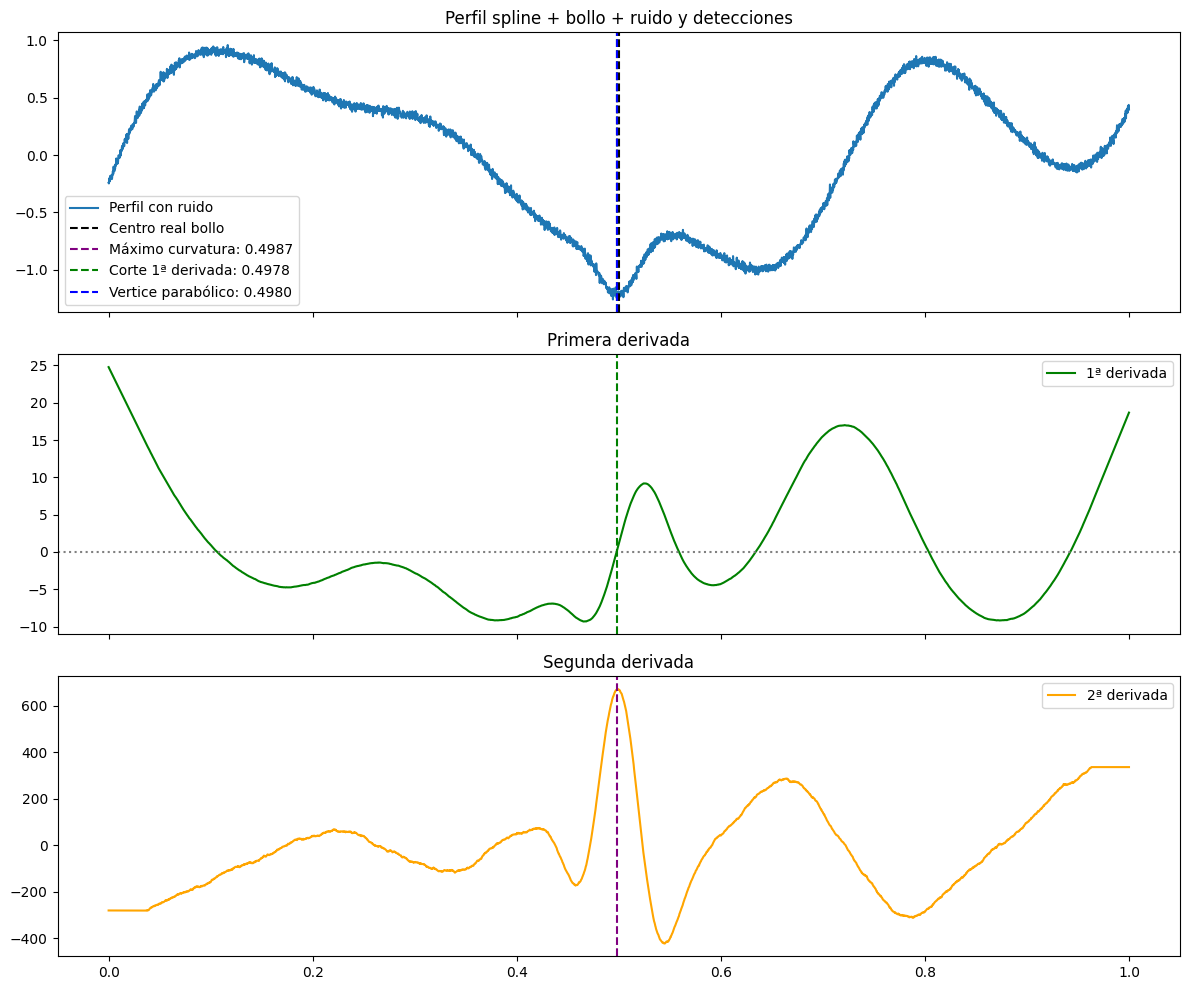

In [6]:
def detectar_bollo_sg_mejorado(x, signal, window_length=101, poly_order=4):
    """
    Versión mejorada:
    - Detecta el máximo de la 2ª derivada
    - Busca el cruce por cero de la 1ª derivada más cercano al máximo de curvatura
    - Ajusta parábola localmente para estimar el centro
    """
    dx = x[1] - x[0]
    d1 = savgol_filter(signal, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx)
    d2 = savgol_filter(signal, window_length=window_length, polyorder=poly_order, deriv=2, delta=dx)

    i_max2 = np.argmax(d2)
    x_max2 = x[i_max2]

    # Cruces por cero (1ª derivada)
    f_interp = interp1d(x, d1, kind='linear')
    sign_change_indices = np.where(np.diff(np.sign(d1)))[0]
    zero_crossings = []
    for idx in sign_change_indices:
        x0, x1 = x[idx], x[idx + 1]
        y0, y1 = d1[idx], d1[idx + 1]
        x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
        zero_crossings.append(x_zero)
    zero_crossings = np.array(zero_crossings)

    # Cruce más cercano al máximo de la segunda derivada
    i_closest_to_max2 = np.argmin(np.abs(zero_crossings - x_max2))
    zero_crossing_x = zero_crossings[i_closest_to_max2]

    # Ajuste parabólico local alrededor del máximo de curvatura
    fit_range = slice(i_max2 - window_length//2, i_max2 + window_length//2 + 1)
    x_fit = x[fit_range] - x[i_max2]
    y_fit = signal[fit_range]
    a, b, c = np.polyfit(x_fit, y_fit, 2)
    vertex_x = x[i_max2] - b / (2 * a)

    return {
        'x_max2': x_max2,
        'x_zero': zero_crossing_x,
        'x_vertex': vertex_x,
        'd1': d1,
        'd2': d2
    }

# Crear señal spline + bollo + ruido
np.random.seed(42)
spline_base = spline(x)
signal_ruidoso = spline_base + gaussian_bump + np.random.normal(0, 0.02, size=len(x))

# Aplicar detector mejorado
res_r = detectar_bollo_sg_mejorado(x, signal_ruidoso, window_length=301, poly_order=2)

# Graficar
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].plot(x, signal_ruidoso, label='Perfil con ruido')
axs[0].axvline(bump_center, color='black', linestyle='--', label='Centro real bollo')
axs[0].axvline(res_r['x_max2'], color='purple', linestyle='--', label=f'Máximo curvatura: {res_r["x_max2"]:.4f}')
axs[0].axvline(res_r['x_zero'], color='green', linestyle='--', label=f'Corte 1ª derivada: {res_r["x_zero"]:.4f}')
axs[0].axvline(res_r['x_vertex'], color='blue', linestyle='--', label=f'Vertice parabólico: {res_r["x_vertex"]:.4f}')
axs[0].set_title("Perfil spline + bollo + ruido y detecciones")
axs[0].legend()

axs[1].plot(x, res_r['d1'], label='1ª derivada', color='green')
axs[1].axhline(0, color='gray', linestyle=':')
axs[1].axvline(res_r['x_zero'], color='green', linestyle='--')
axs[1].set_title("Primera derivada")
axs[1].legend()

axs[2].plot(x, res_r['d2'], label='2ª derivada', color='orange')
axs[2].axvline(res_r['x_max2'], color='purple', linestyle='--')
axs[2].set_title("Segunda derivada")
axs[2].legend()

plt.tight_layout()
plt.show()


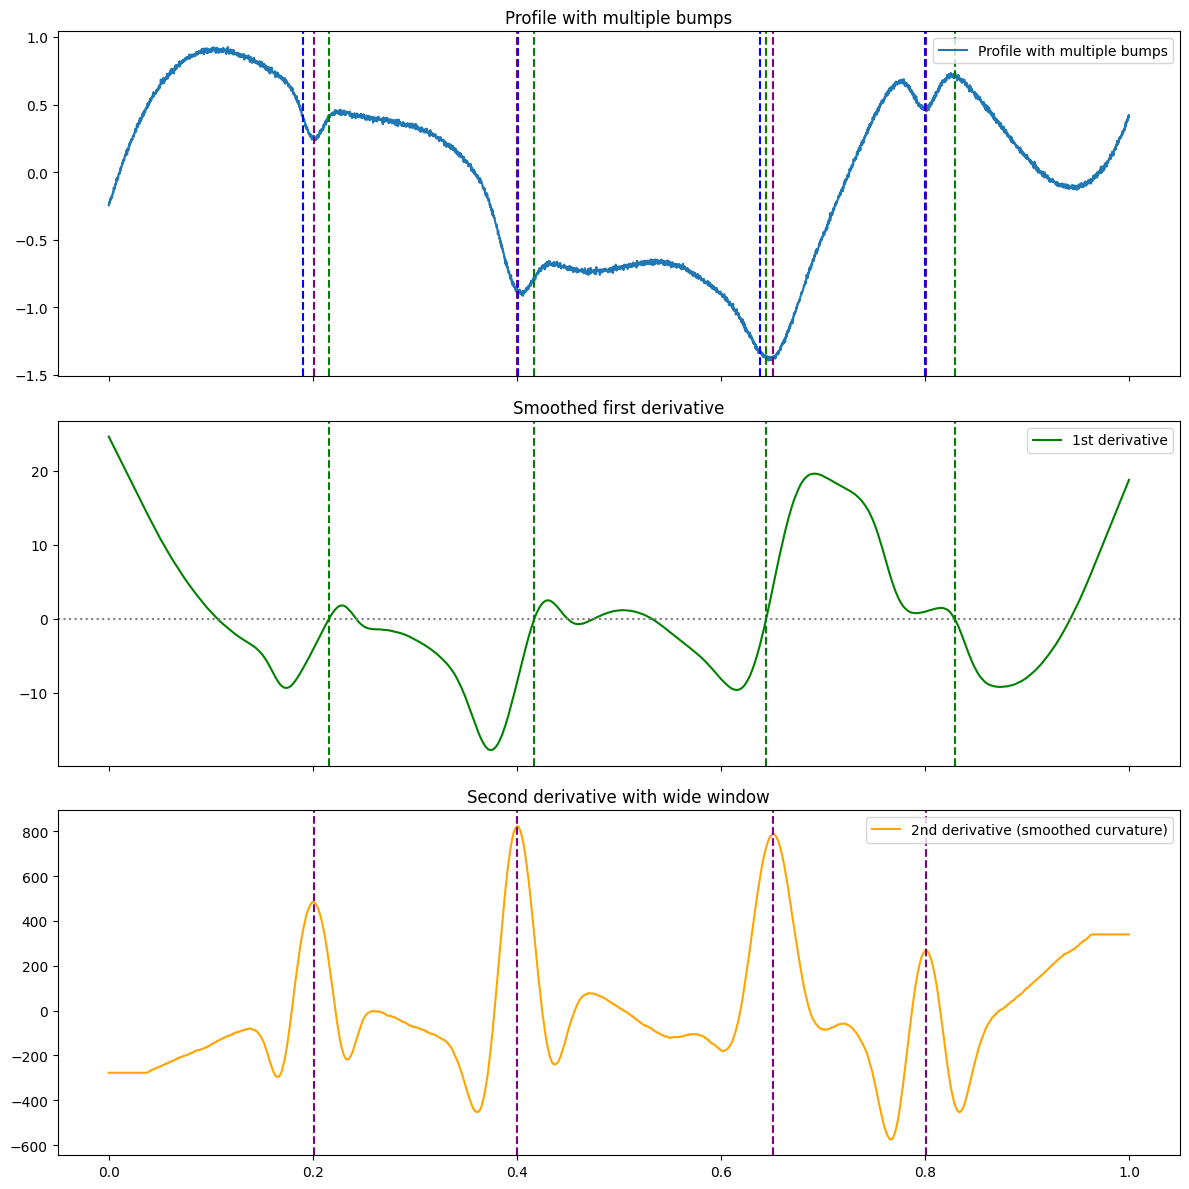

In [7]:
# Generate profile with spline background and multiple Gaussian bumps
np.random.seed(42)
spline_multi = UnivariateSpline(knot_x, knot_y, k=3, s=0)
background_multi = spline_multi(x)

# Define bumps (centers and widths)
bumps_info = [(0.2, 0.01, -0.3), (0.4, 0.015, -0.5), (0.65, 0.02, -0.4), (0.8, 0.012, -0.35)]
bumps = sum(
    amp * np.exp(-((x - xc)**2) / (2 * w**2))
    for xc, w, amp in bumps_info
)
profile_multi = background_multi + bumps + np.random.normal(0, 0.01, len(x))

# Recalculate derivatives with a wider window for more smoothing
wider_window = 301
d1_multi_wide = savgol_filter(profile_multi, window_length=wider_window, polyorder=2, deriv=1, delta=x[1] - x[0])
d2_multi_wide = savgol_filter(profile_multi, window_length=wider_window, polyorder=2, deriv=2, delta=x[1] - x[0])

# Detect peaks of the second derivative above a higher threshold
from scipy.signal import find_peaks

# Adjust threshold and refine peak detection with `find_peaks` using `prominence` and `width`
curv_threshold = 200  # realistic threshold
min_prominence = 100  # minimum prominence to avoid false peaks
min_distance = 100    # minimum separation between peaks

# Recalculate peaks with stricter criteria
peaks_indices_strict, _ = find_peaks(
    d2_multi_wide,
    height=curv_threshold,
    prominence=min_prominence,
    distance=min_distance,
    width=3  # consider more than 3 points of width
)
x_peaks_strict = x[peaks_indices_strict]

# Detect zero crossings and parabolic vertices
detections_wide = []
for i_peak in peaks_indices_strict:
    x_peak = x[i_peak]

    # Closest zero crossing to the peak
    sign_change = np.where(np.diff(np.sign(d1_multi_wide)))[0]
    zero_crossings = []
    for idx in sign_change:
        x0, x1 = x[idx], x[idx + 1]
        y0, y1 = d1_multi_wide[idx], d1_multi_wide[idx + 1]
        x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
        zero_crossings.append(x_zero)
    zero_crossings = np.array(zero_crossings)
    i_nearest = np.argmin(np.abs(zero_crossings - x_peak))
    x_zero = zero_crossings[i_nearest]

    # Local parabolic fit
    fit_range = slice(i_peak - 10, i_peak + 11)
    x_fit = x[fit_range] - x[i_peak]
    y_fit = profile_multi[fit_range]
    a, b, c = np.polyfit(x_fit, y_fit, 2)
    x_vertex = x[i_peak] - b / (2 * a)

    detections_wide.append({
        'peak': x_peak,
        'zero': x_zero,
        'vertex': x_vertex
    })

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axs[0].plot(x, profile_multi, label='Profile with multiple bumps')
axs[0].set_title("Profile with multiple bumps")
axs[0].legend()
for d in detections_wide:
    axs[0].axvline(d['peak'], color='purple', linestyle='--')
    axs[0].axvline(d['zero'], color='green', linestyle='--')
    axs[0].axvline(d['vertex'], color='blue', linestyle='--')

axs[1].plot(x, d1_multi_wide, label='1st derivative', color='green')
axs[1].axhline(0, color='gray', linestyle=':')
for d in detections_wide:
    axs[1].axvline(d['zero'], color='green', linestyle='--')
axs[1].set_title("Smoothed first derivative")
axs[1].legend()

axs[2].plot(x, d2_multi_wide, label='2nd derivative (smoothed curvature)', color='orange')
for d in detections_wide:
    axs[2].axvline(d['peak'], color='purple', linestyle='--')
axs[2].set_title("Second derivative with wide window")
axs[2].legend()

plt.tight_layout()
plt.show()


# MALA ESTIMACIÓN, MÁS ABAJO SE RETOMA


### ¿Qué significa el "ancho" de una parábola?

Para una parábola de la forma:

$$
f(x) = ax^2 + bx + c
$$

- Si $a > 0$, la parábola abre hacia arriba (mínimo).
- Si $a < 0$, abre hacia abajo (máximo).
- El **ancho** de la parábola se puede interpretar como qué tan "abierta" o "cerrada" es.

---

### Aproximación del ancho

Una medida práctica del ancho es la **distancia entre los puntos donde la parábola alcanza un cierto valor por encima del vértice**. Por ejemplo, si el vértice está en $f(x_0)$, podemos definir una cota vertical $f(x_0) + h$, y resolver:

$$
f(x) = a(x - x_0)^2 + f(x_0) = f(x_0) + h
$$

$$
\Rightarrow a(x - x_0)^2 = h
$$

$$
\Rightarrow x - x_0 = \pm \sqrt{\frac{h}{a}}
$$

Entonces, la distancia entre los dos puntos a esa altura es:

$$
\Delta x = 2\sqrt{\frac{h}{|a|}}
$$

Por tanto, **el ancho es inversamente proporcional a $\sqrt{|a|}$**.

---

### Conclusión práctica

Puedes definir un parámetro de apertura o ancho de la parábola así:

$$
\text{Width}_{h} = 2\sqrt{\frac{h}{|a|}}
$$

Donde:
- $h$ es una altura arbitraria elegida (por ejemplo, 0.1 o 1.0 según la escala de tu señal).
- $a$ es el coeficiente cuadrático del ajuste local.

Esto te permite:
- Comparar qué tan "estrechos" o "anchos" son distintos bollos.
- Aplicar umbrales para filtrar bollos demasiado amplios o estrechos.


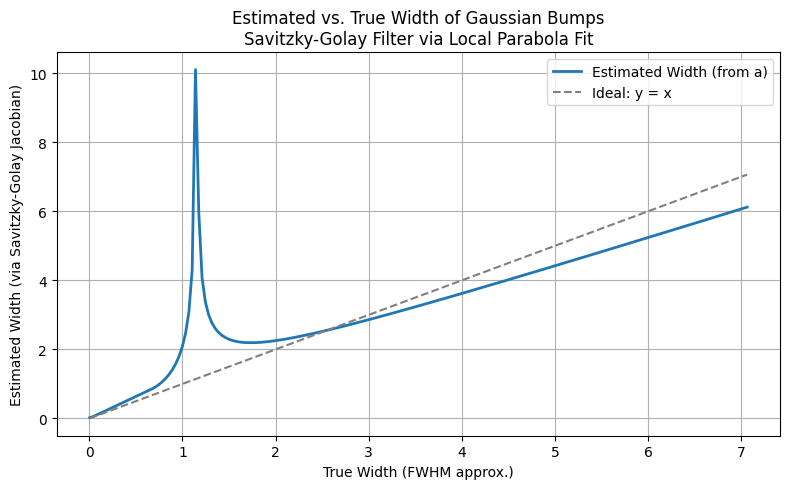

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==== Configuración del dominio ====
x = np.linspace(0, 1, 4096)
dx = x[1] - x[0]
center = 0.5
window_length = 101
half_win = window_length // 2
poly_order = 2

# ==== Función para generar un bump gaussiano ====
def gaussian_bump(x, mu, sigma=0.01, amplitude=-1.0):
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma)**2)

# ==== Filtro de Savitzky-Golay usando ajuste polinómico por Jacobiano ====
def savgol_jacobian_full(signal, x, window_length=101, poly_order=2):
    dx = x[1] - x[0]
    half_win = window_length // 2
    x_local = np.arange(-half_win, half_win + 1) * dx

    # Construir matriz de diseño J para polinomio de segundo grado
    J = np.vstack([x_local**2, x_local, np.ones_like(x_local)]).T
    JTJ_inv = np.linalg.inv(J.T @ J)
    J_pinv = JTJ_inv @ J.T

    # Aplicar el filtro a lo largo de la señal
    a_vals, b_vals, c_vals = [], [], []
    for i in range(half_win, len(x) - half_win):
        y_window = signal[i - half_win:i + half_win + 1]
        beta = J_pinv @ y_window
        a_vals.append(beta[0])
        b_vals.append(beta[1])
        c_vals.append(beta[2])

    x_valid = x[half_win: -half_win]
    return x_valid, {"a": np.array(a_vals), "b": np.array(b_vals), "c": np.array(c_vals)}

# ==== Experimento: estimación de ancho ====
sigmas_dense = np.linspace(0.002, 3, 200)
results = []

for sigma in sigmas_dense:
    bump = gaussian_bump(x, mu=center, sigma=sigma, amplitude=-1)
    signal = 2 * x - 1 + bump

    x_valid, coeffs = savgol_jacobian_full(signal, x, window_length=window_length, poly_order=2)

    i_max_curv = np.argmin(coeffs["a"])
    a = coeffs["a"][i_max_curv]

    h = 0.5  # altura relativa usada para estimar el ancho
    width_est = 2 * np.sqrt(h / abs(a))
    true_width = 2.355 * sigma  # FWHM aproximado para gaussiana

    results.append({
        "sigma_true": sigma,
        "true_width_approx": true_width,
        "a": a,
        "width_estimated": width_est
    })

# ==== Visualización ====
df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
plt.plot(df["true_width_approx"], df["width_estimated"], label="Estimated Width (from a)", lw=2)
plt.plot(df["true_width_approx"], df["true_width_approx"], '--', color='gray', label="Ideal: y = x")
plt.xlabel("True Width (FWHM approx.)")
plt.ylabel("Estimated Width (via Savitzky-Golay Jacobian)")
plt.title("Estimated vs. True Width of Gaussian Bumps\nSavitzky-Golay Filter via Local Parabola Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Experimento detección bollos otra vez


$x_{vertex} = x_0 - \frac{b}{2a}$
​

Sobre línea de valor 0

In [9]:
def sg_jacobian_projection(x: np.ndarray, y: np.ndarray, window_length: int = 151):
    """
    Aplica un filtro de Savitzky-Golay mediante proyección Jacobiana
    sobre una señal 1D, ajustando un polinomio cuadrático en ventanas deslizantes.

    Parámetros:
        x (np.ndarray): Vector de posiciones (eje x).
        y (np.ndarray): Vector de valores de la señal (eje y), del mismo tamaño que x.
        window_length (int): Longitud de la ventana (debe ser impar).

    Retorna:
        x_valid (np.ndarray): Puntos x donde la aproximación es válida.
        a_vals (np.ndarray): Coeficientes cuadráticos (curvatura).
        b_vals (np.ndarray): Coeficientes lineales (pendiente).
        c_vals (np.ndarray): Coeficientes constantes (offset).
    """
    assert window_length % 2 == 1, "window_length debe ser impar"
    assert len(x) == len(y), "x e y deben tener la misma longitud"

    dx = x[1] - x[0]
    half_win = window_length // 2
    x_local = np.arange(-half_win, half_win + 1) * dx

    # Matriz de diseño del Jacobiano
    J = np.vstack([x_local**2, x_local, np.ones_like(x_local)]).T
    JTJ_inv = np.linalg.inv(J.T @ J)
    J_pinv = JTJ_inv @ J.T

    # Aplicar proyección local
    a_vals, b_vals, c_vals = [], [], []
    for i in range(half_win, len(x) - half_win):
        y_window = y[i - half_win:i + half_win + 1]
        beta = J_pinv @ y_window
        a_vals.append(beta[0])
        b_vals.append(beta[1])
        c_vals.append(beta[2])

    x_valid = x[half_win: -half_win]
    return x_valid, np.array(a_vals), np.array(b_vals), np.array(c_vals)

   curvature_peak  a (Jacobian)  b (Jacobian)    vertex  true_center     error
0        0.099878    432.596887     -0.083095  0.099974         0.10  0.000026
1        0.200000    788.946872      0.131284  0.199917         0.20  0.000083
2        0.350183    575.787300      0.255336  0.349961         0.35  0.000039
3        0.499878    330.683013     -0.110108  0.500044         0.50  0.000044
4        0.646886    266.430961     -1.508725  0.649718         0.65  0.000282
5        0.749695    739.593197      0.000739  0.749694         0.75  0.000306
6        0.900122    287.386370      0.015345  0.900095         0.90  0.000095


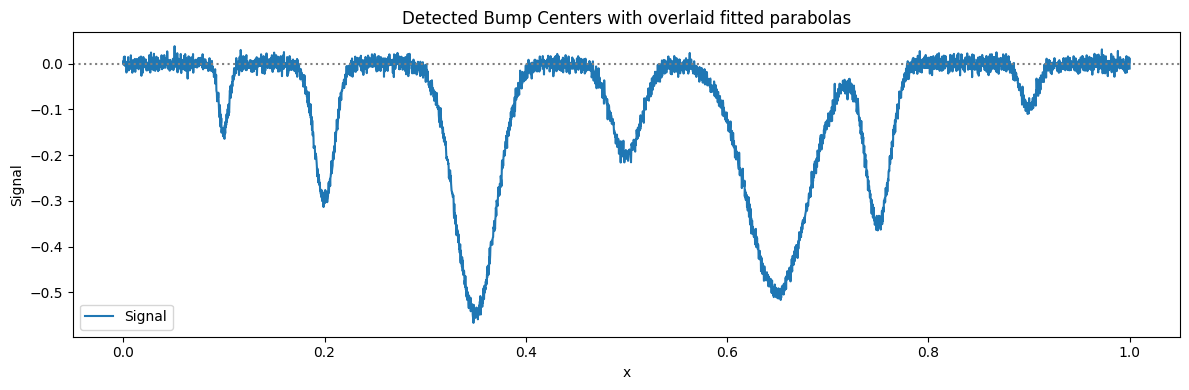

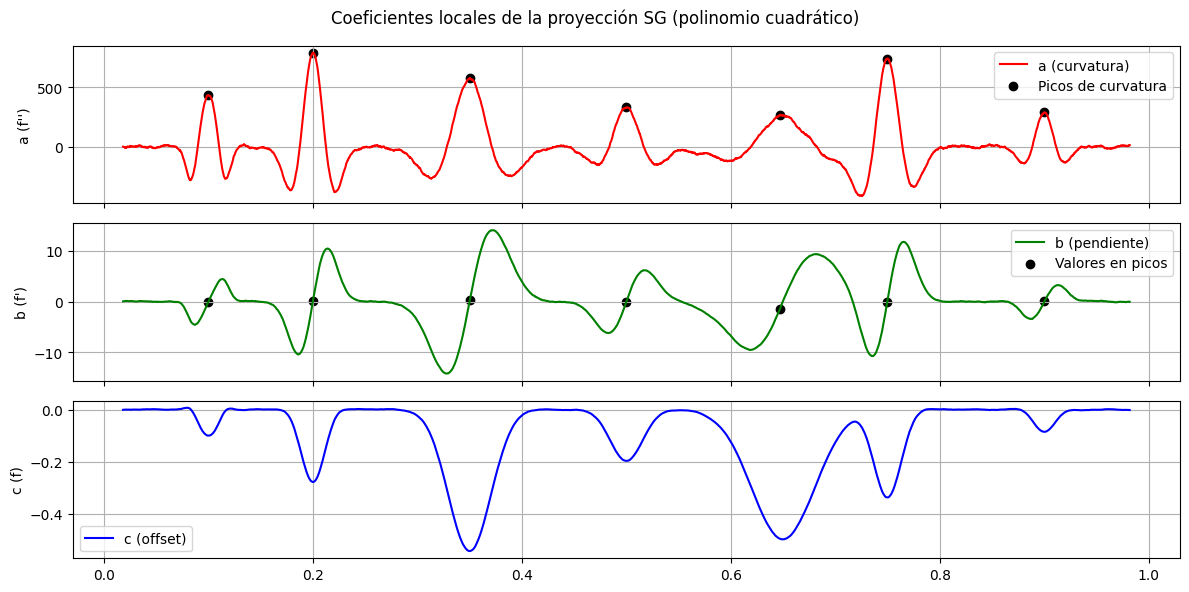

In [39]:
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist

# ===========================
# 1. Generate synthetic signal: bumps on flat line
# ===========================
x = np.linspace(0, 1, 4096)
dx = x[1] - x[0]

# Flat background
flat_background = np.zeros_like(x)

# Define bumps: (center, sigma, amplitude)
# Nuevos defectos: (center, sigma, amplitude)
bumps_info = [
    (0.10, 0.005, -0.15),  # muy estrecho y poco profundo
    (0.20, 0.010, -0.30),
    (0.35, 0.020, -0.55),  # más ancho y profundo
    (0.50, 0.015, -0.20),
    (0.65, 0.030, -0.50),  # muy ancho y profundo
    (0.75, 0.012, -0.35),
    (0.90, 0.008, -0.10)   # estrecho y poco profundo
]
bumps = sum(amp * np.exp(-((x - xc)**2) / (2 * w**2)) for xc, w, amp in bumps_info)

# Combine with optional noise
np.random.seed(42)
profile = flat_background + bumps + np.random.normal(0, 0.01, len(x))



# ===========================
# 2. SG filter via Jacobian projection
# ===========================
x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, profile, window_length=151)


# ===========================
# 3. Detect curvature peaks
# ===========================
curv_threshold = 200
min_prominence = 100
min_distance = 100

peaks_indices, _ = find_peaks(
    a_vals,
    height=curv_threshold / 2,  # a = f''/2 so divide threshold
    prominence=min_prominence / 2,
    distance=min_distance,
    width=3
)
x_peaks = x_valid[peaks_indices]

# ===========================
# 4. Estimate vertex from Jacobian-based a and b
# ===========================
a_detected = a_vals[peaks_indices]
b_detected = b_vals[peaks_indices]
c_detected = c_vals[peaks_indices]

vertices = x_peaks - b_detected / (2 * a_detected)

# ===========================
# 5. Match to true centers
# ===========================
true_centers = np.array([xc for xc, _, _ in bumps_info]).reshape(-1, 1)
assignments = cdist(vertices.reshape(-1, 1), true_centers)
assigned_indices = np.argmin(assignments, axis=1)

# ===========================
# 6. Build results table
# ===========================
df = pd.DataFrame({
    "curvature_peak": x_peaks,
    "a (Jacobian)": a_detected,
    "b (Jacobian)": b_detected,
    "vertex": vertices,
    "true_center": true_centers[assigned_indices].flatten()
})
df["error"] = np.abs(df["vertex"] - df["true_center"])
df = df.sort_values("true_center").reset_index(drop=True)

# ===========================
# 7. Show table and plot
# ===========================
print(df.round(6))

plt.figure(figsize=(12, 4))
plt.plot(x, profile, label="Signal")
plt.axhline(0, color='gray', linestyle=':')

# Dibujar parábolas locales en cada vértice
# x_range = np.linspace(-0.03, 0.03, 100)
# for xv, a, b, c in zip(vertices, a_detected, b_detected, c_detected):
#     x_parab = xv + x_range
#     y_parab = a * x_range**2 + b * x_range + c
#     plt.plot(x_parab, y_parab, color='red', linewidth=1.2, alpha=0.9)

# # Líneas verticales para vértices y picos de curvatura
# for i, row in df.iterrows():
#     plt.axvline(row["vertex"], color='blue', linestyle='--', label='Vertex' if i == 0 else "")
#     plt.axvline(row["curvature_peak"], color='purple', linestyle='--', label='Curvature peak' if i == 0 else "")

plt.legend()
plt.title("Detected Bump Centers with overlaid fitted parabolas")
plt.xlabel("x")
plt.ylabel("Signal")
plt.tight_layout()
plt.show()


# ===========================
# Plot a, b, c vs x
# ===========================
c_vals = np.array(c_vals)

fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# --- a(x)
axs[0].plot(x_valid, a_vals, label="a (curvatura)", color='red')
axs[0].scatter(x_peaks, a_detected, color='black', label="Picos de curvatura")
axs[0].set_ylabel("a (f'')")
axs[0].legend()
axs[0].grid(True)

# --- b(x)
axs[1].plot(x_valid, b_vals, label="b (pendiente)", color='green')
axs[1].scatter(x_peaks, b_detected, color='black', label="Valores en picos")
axs[1].set_ylabel("b (f')")
axs[1].legend()
axs[1].grid(True)

# --- c(x)
axs[2].plot(x_valid, c_vals, label="c (offset)", color='blue')
axs[2].set_ylabel("c (f)")
axs[2].legend()
axs[2].grid(True)

# --- parábolas locales
# axs[3].set_title("Parábolas locales ajustadas")
# slice = 50
# for xi, a, b, c in zip(x_valid[::slice], a_vals[::slice], b_vals[::slice], c_vals[::slice]):
#     x_local = np.linspace(-0.02, 0.02, 100)
#     y_local = a * x_local**2 + b * x_local + c
#     axs[3].plot(xi + x_local, y_local, color='gray', alpha=0.7)
# axs[3].set_ylabel("Ajuste parabólico")
# axs[3].set_xlabel("x")
# axs[3].grid(True)
plt.suptitle("Coeficientes locales de la proyección SG (polinomio cuadrático)")
plt.tight_layout()
plt.show()


## 📏 ¿Cómo estimar el ancho de un defecto?

### 📘 ¿Qué es el *focal width*?

En la parábola vertical:

$$
x^2 = 4py
$$

- El vértice está en el origen.
- El foco está en $(0, p)$.
- La **línea horizontal** que pasa por el foco (es decir, $y = p$) intersecta la parábola en dos puntos:
    $A = (-2p, p)$,
    $A' = (2p, p)$

Por tanto, la distancia entre esos dos puntos es:

$$
\text{Focal Width} = AA' = 4p
$$

---

### 📏 Estimación del ancho usando el *focal width*

Dado que al ajustar una parábola a tu defecto obtienes:

$$
y = ax^2 + bx + c
$$

y cerca del vértice se puede reescribir como:

$$
y = \frac{1}{4p}(x - h)^2 + k
\quad \Rightarrow \quad
a = \frac{1}{4p}
$$

Entonces:

$$
4p = \frac{1}{a}
$$

Así que:

$$
\text{Ancho estimado del defecto (focal width)} = \frac{1}{a}
$$

---

### 🧠 Conclusión

- **Sí**, el concepto de *focal width* (longitud del acorde focal) es una excelente forma de estimar el **ancho del defecto**.
- Es directo, simple (solo necesitas $a$) y tiene una **base geométrica clara**.
- Puede ser incluso más intuitivo que usar la raíz cuadrada para muchos casos.


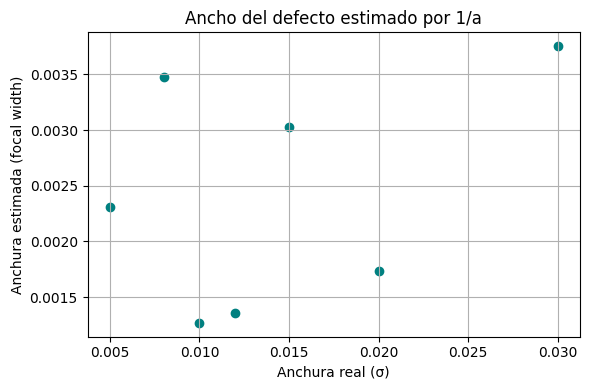

Correlación anchura real vs focal width (1/a): 0.372


In [40]:
# Extrae info real desde bumps_info
true_amplitudes = np.array([amp for _, _, amp in bumps_info])
true_sigmas = np.array([sigma for _, sigma, _ in bumps_info])
true_centers = np.array([xc for xc, _, _ in bumps_info]).reshape(-1, 1)

# Asigna cada vértice detectado a un centro real
assignments = cdist(vertices.reshape(-1, 1), true_centers)
assigned_indices = np.argmin(assignments, axis=1)

# Construye el DataFrame
comparison_df = pd.DataFrame({
    "true_amplitude": true_amplitudes[assigned_indices],
    "true_sigma": true_sigmas[assigned_indices],
    "a_detected": a_detected,
    "b_detected": b_detected,
    "c_detected": c_detected,
    "vertex": vertices
})

# ===========================
# Estimar ancho como focal width: 1 / a
# ===========================
with np.errstate(divide='ignore', invalid='ignore'):
    focal_width = np.where(comparison_df["a_detected"] != 0,
                           1 / comparison_df["a_detected"],
                           np.nan)

comparison_df["estimated_width_focal"] = np.abs(focal_width)  # usamos valor absoluto por si a < 0

# ===========================
# Comparar con anchura real
# ===========================
valid_focal = np.isfinite(comparison_df["estimated_width_focal"]) & np.isfinite(comparison_df["true_sigma"])
plt.figure(figsize=(6, 4))
plt.scatter(comparison_df["true_sigma"][valid_focal], comparison_df["estimated_width_focal"][valid_focal], color='teal')
plt.xlabel("Anchura real (σ)")
plt.ylabel("Anchura estimada (focal width)")
plt.title("Ancho del defecto estimado por 1/a")
plt.grid(True)
plt.tight_layout()
plt.show()

if valid_focal.sum() >= 2:
    corr_focal = np.corrcoef(comparison_df["true_sigma"][valid_focal], comparison_df["estimated_width_focal"][valid_focal])[0, 1]
    print(f"Correlación anchura real vs focal width (1/a): {corr_focal:.3f}")
else:
    print("No hay suficientes datos válidos para correlación focal width.")


## 🔍 ¿Por qué el ajuste parabólico funciona en tu caso?

1. **El ajuste es local**:
   - Usas una ventana corta (`window_length=151`) sobre 4096 puntos → el ajuste solo captura la zona central del defecto.
   - En ese rango, la gaussiana es **muy parecida a una parábola**.

2. **Visualmente las parábolas ajustadas (líneas rojas) coinciden muy bien con la parte inferior de los defectos**.
   - Esto significa que `a` (la curvatura) realmente captura la **segunda derivada local**.
   - Y por tanto sí es razonable que el parámetro `a` esté relacionado con las propiedades de la gaussiana original.

3. **Tienes una buena relación señal/ruido**:
   - Aunque hay ruido, la forma general del defecto domina claramente.
   - Eso permite que la proyección Jacobiana recupere bien los parámetros del polinomio.

---

## 💡 Entonces... ¿por qué?

Porque para una **gaussiana pura**:

$f(x) = A \cdot e^{-\frac{(x - x_0)^2}{2\sigma^2}} \quad \Rightarrow \quad f''(x_0) = -\frac{A}{\sigma^2}$

Y como tu parábola ajustada da:

$f(x) \approx ax^2 + bx + c \quad \Rightarrow \quad f''(x_0) = 2a$

Entonces:

$a \approx -\frac{A}{2\sigma^2}
\quad \Rightarrow \quad
\sigma^2 \approx -\frac{A}{2a}
\quad \Rightarrow \quad
\sigma \approx \sqrt{-\frac{A}{2a}}$

Así que la estimación correcta de **anchura (σ)** debería ser:

$\text{estimated\_sigma} = \sqrt{\frac{|A|}{2|a|}}$

Aunque al principio decíamos que no conoces $A$ (la **profundidad real del defecto**), **sí puedes estimarla razonablemente** a partir del valor de la señal **en el vértice de la parábola ajustada**, ya que:

---

### 📌 En la parábola ajustada:

$$
f(x) = a(x - x_0)^2 + b(x - x_0) + c
$$

o directamente, si usas:

$$
f(x) = ax^2 + bx + c
$$

el **mínimo (vértice)** está en:

$$
x_v = -\frac{b}{2a}
$$

y el **valor en ese punto** es:

$$
f(x_v) = a x_v^2 + b x_v + c
$$

👉 Este valor representa una **estimación de la profundidad del defecto**, y por tanto una **estimación de $A$** (tomando el valor negativo si el defecto es hacia abajo).

---

### ✅ Entonces sí: puedes estimar $A$ como

$$
A_{\text{estimado}} = -f(x_v)
$$

(y el signo negativo es porque los defectos son baches → negativos)


### ✅ Conclusión

Ahora tienes un estimador **completamente autosuficiente**, usando solo:

- $a$ (curvatura),
- $b$, $c$,
- y el vértice $x_v$.

👉 Todo **obtenido localmente desde la proyección parabólica**, **sin necesidad de conocer $A$ real ni $σ$ real**, pero aún así **puedes estimarlos razonablemente bien**.

¿Quieres que empaquete esto en una única función que te dé tanto $A$ como $σ$ estimados desde los coeficientes $a$, $b$, $c$?

In [41]:
# Asegúrate de tener esta función definida
def estimate_gaussian_params_from_parabola(a, b, c):
    a = np.asarray(a)
    b = np.asarray(b)
    c = np.asarray(c)
    x_v = -b / (2 * a)
    f_v = a * x_v**2 + b * x_v + c
    estimated_A = -f_v
    with np.errstate(divide='ignore', invalid='ignore'):
        estimated_sigma = np.sqrt(estimated_A / (2 * np.abs(a)))
    return estimated_A, estimated_sigma


comparison_df["A_hat"], comparison_df["sigma_hat"] = estimate_gaussian_params_from_parabola(
    comparison_df["a_detected"],
    comparison_df["b_detected"],
    comparison_df["c_detected"]
)

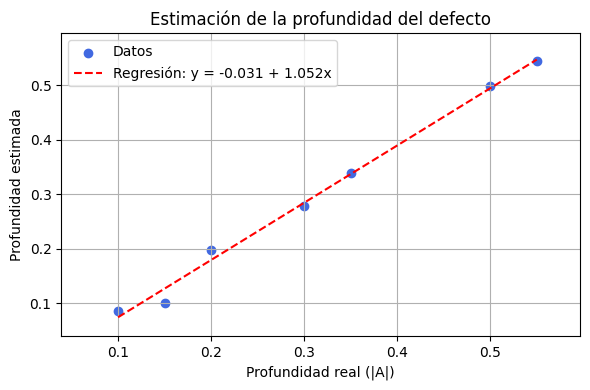

Correlación A real vs A estimado: 0.997


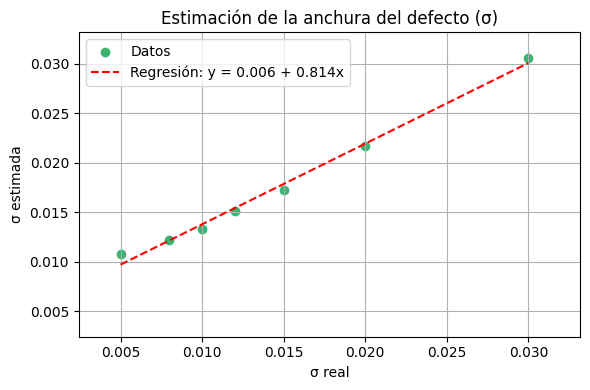

Correlación σ real vs estimada: 0.996


In [42]:
from numpy.polynomial.polynomial import polyfit

# ===========================
# Profundidad A: estimado vs real
# ===========================
valid_A = np.isfinite(comparison_df["A_hat"]) & np.isfinite(comparison_df["true_amplitude"])
x_A = -comparison_df["true_amplitude"][valid_A]
y_A = comparison_df["A_hat"][valid_A]

plt.figure(figsize=(6, 4))
plt.scatter(x_A, y_A, color='royalblue', label="Datos")

# Recta de correlación (regresión lineal)
b0, b1 = polyfit(x_A, y_A, 1)  # y ≈ b0 + b1*x
x_line = np.linspace(x_A.min(), x_A.max(), 100)
plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Regresión: y = {b0:.3f} + {b1:.3f}x')

# Límites ajustados
min_A = min(x_A.min(), y_A.min())
max_A = max(x_A.max(), y_A.max())
range_A = max_A - min_A
plt.xlim(min_A - 0.1 * range_A, max_A + 0.1 * range_A)
plt.ylim(min_A - 0.1 * range_A, max_A + 0.1 * range_A)

plt.xlabel("Profundidad real (|A|)")
plt.ylabel("Profundidad estimada")
plt.title("Estimación de la profundidad del defecto")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if valid_A.sum() >= 2:
    corr_A = np.corrcoef(x_A, y_A)[0, 1]
    print(f"Correlación A real vs A estimado: {corr_A:.3f}")
else:
    print("No hay suficientes datos válidos para correlación de A.")


# ===========================
# Anchura σ: estimado vs real
# ===========================
valid_sigma = np.isfinite(comparison_df["sigma_hat"]) & np.isfinite(comparison_df["true_sigma"])
x_sigma = comparison_df["true_sigma"][valid_sigma]
y_sigma = comparison_df["sigma_hat"][valid_sigma]

plt.figure(figsize=(6, 4))
plt.scatter(x_sigma, y_sigma, color='mediumseagreen', label="Datos")

# Recta de correlación (regresión lineal)
b0, b1 = polyfit(x_sigma, y_sigma, 1)
x_line = np.linspace(x_sigma.min(), x_sigma.max(), 100)
plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Regresión: y = {b0:.3f} + {b1:.3f}x')

# Límites ajustados
min_sigma = min(x_sigma.min(), y_sigma.min())
max_sigma = max(x_sigma.max(), y_sigma.max())
range_sigma = max_sigma - min_sigma
plt.xlim(min_sigma - 0.1 * range_sigma, max_sigma + 0.1 * range_sigma)
plt.ylim(min_sigma - 0.1 * range_sigma, max_sigma + 0.1 * range_sigma)

plt.xlabel("σ real")
plt.ylabel("σ estimada")
plt.title("Estimación de la anchura del defecto (σ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if valid_sigma.sum() >= 2:
    corr_sigma = np.corrcoef(x_sigma, y_sigma)[0, 1]
    print(f"Correlación σ real vs estimada: {corr_sigma:.3f}")
else:
    print("No hay suficientes datos válidos para correlación de σ.")


### Sobre spline

   curvature_peak  a (Jacobian)  b (Jacobian)    vertex  true_center     error
0        0.100611    437.914287      0.243262  0.100333         0.10  0.000333
1        0.200000    790.570297      0.084776  0.199946         0.20  0.000054
2        0.349206    565.710059     -0.816375  0.349928         0.35  0.000072
3        0.501587    336.157528      0.942230  0.500186         0.50  0.000186
4        0.649817    232.742030      0.096905  0.649609         0.65  0.000391
5        0.750183    775.776273     -1.273050  0.751004         0.75  0.001004
6        0.899878    287.257286     -0.111231  0.900072         0.90  0.000072


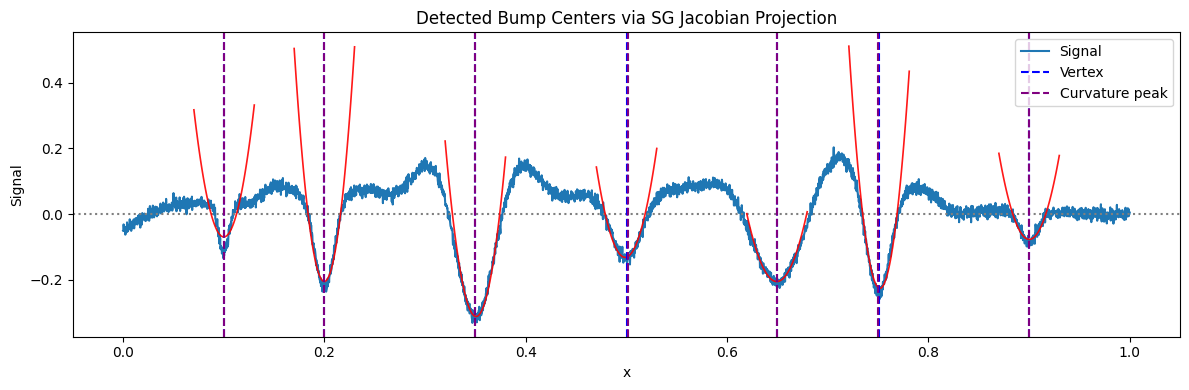

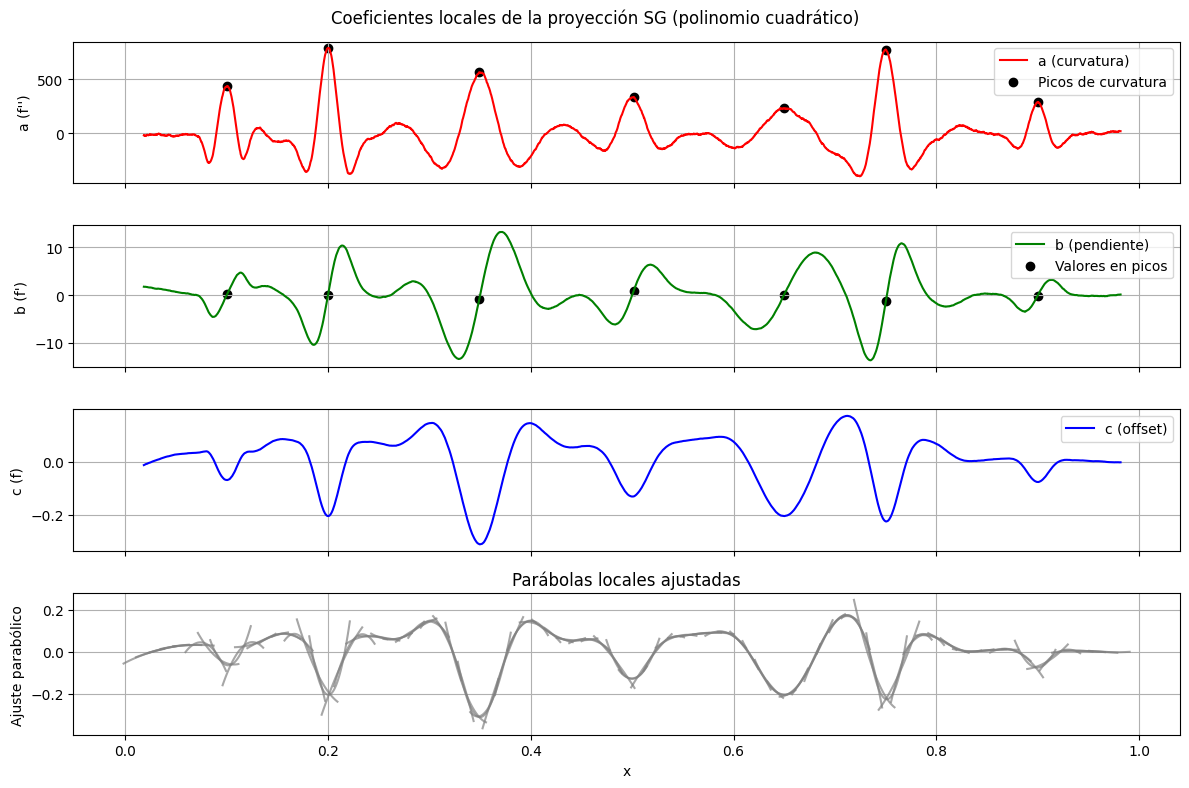

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import find_peaks
from scipy.spatial.distance import cdist

# ===========================
# 1. Signal: spline + bumps
# ===========================
x = np.linspace(0, 1, 4096)
dx = x[1] - x[0]
np.random.seed(42)

# Fondo más suave: menos nodos
knot_x = np.linspace(0, 1, 4)  # solo 4 nodos
knot_y = np.random.uniform(-1, 1, size=len(knot_x))

spline = UnivariateSpline(knot_x, knot_y, k=3, s=0)
background = spline(x)


# Bumps: (center, sigma, amplitude)
bumps_info = [
    (0.10, 0.005, -0.15),  # muy estrecho y poco profundo
    (0.20, 0.010, -0.30),
    (0.35, 0.020, -0.55),  # más ancho y profundo
    (0.50, 0.015, -0.20),
    (0.65, 0.030, -0.50),  # muy ancho y profundo
    (0.75, 0.012, -0.35),
    (0.90, 0.008, -0.10)   # estrecho y poco profundo
]
bumps = sum(amp * np.exp(-((x - xc)**2) / (2 * w**2)) for xc, w, amp in bumps_info)

# Final profile with noise
profile = background + bumps + np.random.normal(0, 0.01, len(x))

# ===========================
# 1.1. Eliminar tendencia mediante un filtro de Savitzky-Golay grande y de grado 1
# ===========================
profile = profile - savgol_filter(profile, window_length=501, polyorder=1)

# ===========================
# 2. SG filter via Jacobian projection
# ===========================
x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, profile, window_length=151)



# ===========================
# 3. Detect curvature peaks
# ===========================
curv_threshold = 200
min_prominence = 100
min_distance = 100

peaks_indices, _ = find_peaks(
    a_vals,
    height=curv_threshold / 2,  # a = f''/2 so divide threshold
    prominence=min_prominence / 2,
    distance=min_distance,
    width=3
)
x_peaks = x_valid[peaks_indices]

# ===========================
# 4. Estimate vertex from Jacobian-based a and b
# ===========================
a_detected = a_vals[peaks_indices]
b_detected = b_vals[peaks_indices]
c_detected = c_vals[peaks_indices]

vertices = x_peaks - b_detected / (2 * a_detected)

# ===========================
# 5. Match to true centers
# ===========================
true_centers = np.array([xc for xc, _, _ in bumps_info]).reshape(-1, 1)
assignments = cdist(vertices.reshape(-1, 1), true_centers)
assigned_indices = np.argmin(assignments, axis=1)

# ===========================
# 6. Build results table
# ===========================
df = pd.DataFrame({
    "curvature_peak": x_peaks,
    "a (Jacobian)": a_detected,
    "b (Jacobian)": b_detected,
    "vertex": vertices,
    "true_center": true_centers[assigned_indices].flatten()
})
df["error"] = np.abs(df["vertex"] - df["true_center"])
df = df.sort_values("true_center").reset_index(drop=True)

# ===========================
# 7. Show table and plot
# ===========================
print(df.round(6))

plt.figure(figsize=(12, 4))
plt.plot(x, profile, label="Signal")
plt.axhline(0, color='gray', linestyle=':')

# Dibujar parábolas locales en cada vértice
x_range = np.linspace(-0.03, 0.03, 100)
for xv, a, b, c in zip(vertices, a_detected, b_detected, c_detected):
    x_parab = xv + x_range
    y_parab = a * x_range**2 + b * x_range + c
    plt.plot(x_parab, y_parab, color='red', linewidth=1.2, alpha=0.9)

# Líneas verticales para vértices y picos de curvatura
for i, row in df.iterrows():
    plt.axvline(row["vertex"], color='blue', linestyle='--', label='Vertex' if i == 0 else "")
    plt.axvline(row["curvature_peak"], color='purple', linestyle='--', label='Curvature peak' if i == 0 else "")

plt.legend()
plt.title("Detected Bump Centers via SG Jacobian Projection")
plt.xlabel("x")
plt.ylabel("Signal")
plt.tight_layout()
plt.show()


# ===========================
# Plot a, b, c vs x
# ===========================
c_vals = np.array(c_vals)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# --- a(x)
axs[0].plot(x_valid, a_vals, label="a (curvatura)", color='red')
axs[0].scatter(x_peaks, a_detected, color='black', label="Picos de curvatura")
axs[0].set_ylabel("a (f'')")
axs[0].legend()
axs[0].grid(True)

# --- b(x)
axs[1].plot(x_valid, b_vals, label="b (pendiente)", color='green')
axs[1].scatter(x_peaks, b_detected, color='black', label="Valores en picos")
axs[1].set_ylabel("b (f')")
axs[1].legend()
axs[1].grid(True)

# --- c(x)
axs[2].plot(x_valid, c_vals, label="c (offset)", color='blue')
axs[2].set_ylabel("c (f)")
axs[2].legend()
axs[2].grid(True)

# --- parábolas locales
axs[3].set_title("Parábolas locales ajustadas")
slice = 50
for xi, a, b, c in zip(x_valid[::slice], a_vals[::slice], b_vals[::slice], c_vals[::slice]):
    x_local = np.linspace(-0.02, 0.02, 100)
    y_local = a * x_local**2 + b * x_local + c
    axs[3].plot(xi + x_local, y_local, color='gray', alpha=0.7)
axs[3].set_ylabel("Ajuste parabólico")
axs[3].set_xlabel("x")
axs[3].grid(True)
plt.suptitle("Coeficientes locales de la proyección SG (polinomio cuadrático)")
plt.tight_layout()
plt.show()




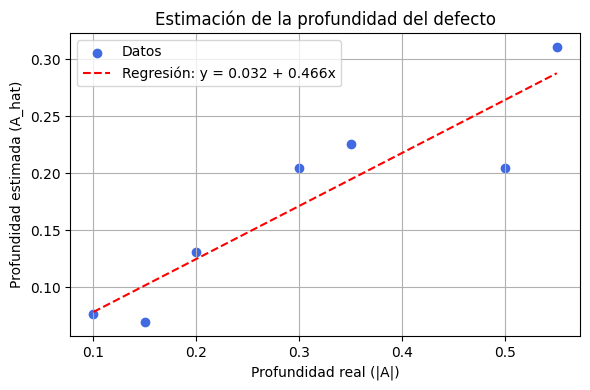

Correlación A real vs A estimado: 0.917


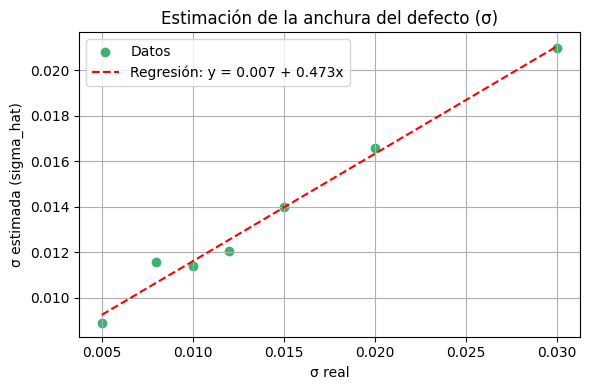

Correlación σ real vs estimada: 0.993


In [15]:
# Aplicar estimación
A_hat, sigma_hat = estimate_gaussian_params_from_parabola(a_detected, b_detected, c_detected)

# Obtener valores reales desde bumps_info
true_amplitudes = np.array([amp for _, _, amp in bumps_info])
true_sigmas = np.array([sigma for _, sigma, _ in bumps_info])
true_centers = np.array([xc for xc, _, _ in bumps_info]).reshape(-1, 1)

# Asignar cada vértice a un centro real
assignments = cdist(vertices.reshape(-1, 1), true_centers)
assigned_indices = np.argmin(assignments, axis=1)

# ===========================
# Crear DataFrame de comparación
# ===========================
comparison_df = pd.DataFrame({
    "true_amplitude": true_amplitudes[assigned_indices],
    "true_sigma": true_sigmas[assigned_indices],
    "a_detected": a_detected,
    "b_detected": b_detected,
    "c_detected": c_detected,
    "estimated_A": A_hat,
    "estimated_sigma": sigma_hat,
})

# ===========================
# Gráfica de correlación A
# ===========================
from numpy.polynomial.polynomial import polyfit

valid_A = np.isfinite(comparison_df["estimated_A"]) & np.isfinite(comparison_df["true_amplitude"])
x_A = -comparison_df["true_amplitude"][valid_A]
y_A = comparison_df["estimated_A"][valid_A]

plt.figure(figsize=(6, 4))
plt.scatter(x_A, y_A, color='royalblue', label="Datos")
b0, b1 = polyfit(x_A, y_A, 1)
x_line = np.linspace(x_A.min(), x_A.max(), 100)
plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Regresión: y = {b0:.3f} + {b1:.3f}x')
plt.xlabel("Profundidad real (|A|)")
plt.ylabel("Profundidad estimada (A_hat)")
plt.title("Estimación de la profundidad del defecto")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if valid_A.sum() >= 2:
    corr_A = np.corrcoef(x_A, y_A)[0, 1]
    print(f"Correlación A real vs A estimado: {corr_A:.3f}")
else:
    print("No hay suficientes datos válidos para correlación de A.")

# ===========================
# Gráfica de correlación sigma
# ===========================
valid_sigma = np.isfinite(comparison_df["estimated_sigma"]) & np.isfinite(comparison_df["true_sigma"])
x_sigma = comparison_df["true_sigma"][valid_sigma]
y_sigma = comparison_df["estimated_sigma"][valid_sigma]

plt.figure(figsize=(6, 4))
plt.scatter(x_sigma, y_sigma, color='mediumseagreen', label="Datos")
b0, b1 = polyfit(x_sigma, y_sigma, 1)
x_line = np.linspace(x_sigma.min(), x_sigma.max(), 100)
plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Regresión: y = {b0:.3f} + {b1:.3f}x')
plt.xlabel("σ real")
plt.ylabel("σ estimada (sigma_hat)")
plt.title("Estimación de la anchura del defecto (σ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if valid_sigma.sum() >= 2:
    corr_sigma = np.corrcoef(x_sigma, y_sigma)[0, 1]
    print(f"Correlación σ real vs estimada: {corr_sigma:.3f}")
else:
    print("No hay suficientes datos válidos para correlación de σ.")

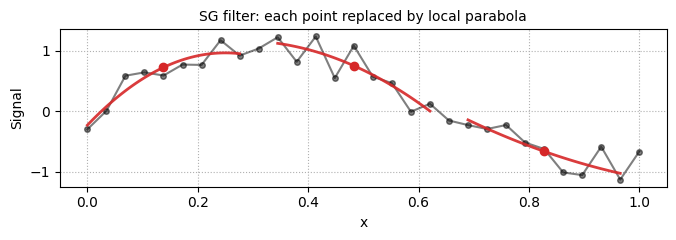

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 1. Simple signal
# -----------------------
x = np.linspace(0, 1, 30)
signal = np.sin(1.5 * np.pi * x) + 0.2 * np.random.randn(len(x))

# -----------------------
# 2. SG projection parameters
# -----------------------
window_length = 9
half_win = window_length // 2
dx = x[1] - x[0]
x_local = np.arange(-half_win, half_win + 1) * dx

# Design matrix
J = np.vstack([x_local**2, x_local, np.ones_like(x_local)]).T
J_pinv = np.linalg.inv(J.T @ J) @ J.T

# Selected centers (well spaced, no overlap)
centers = [4, 14, 24]

# -----------------------
# 3. Plot
# -----------------------
plt.figure(figsize=(7, 2.5))
plt.plot(x, signal, 'ko-', label="Noisy signal", markersize=4, alpha=0.5)

for idx in centers:
    x0 = x[idx]
    y_window = signal[idx - half_win : idx + half_win + 1]
    a, b, c = J_pinv @ y_window

    # Local parabola
    x_fit = np.linspace(-half_win * dx, half_win * dx, 100)
    y_fit = a * x_fit**2 + b * x_fit + c
    plt.plot(x0 + x_fit, y_fit, color='tab:red', lw=2, alpha=0.9)

    # Smoothed value
    y_smooth = c
    plt.plot(x0, y_smooth, 'o', color='tab:red', markersize=6)

# -----------------------
# 4. Styling
# -----------------------
plt.title("SG filter: each point replaced by local parabola", fontsize=10)
plt.xlabel("x")
plt.ylabel("Signal")
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()
